In [399]:
# 📊 Exploratory Data Analysis (EDA) on Spotify Songs Dataset (2023)
# Objective:
# To analyze factors influencing song popularity using features like streams,
# playlists, charts presence, and audio characteristics (danceability, energy, bpm, etc.)

# Key Analysis Includes:
# - Data cleaning & preprocessing
# - Top vs bottom songs comparison
# - Artist analysis (solo vs collaboration)
# - Time-based trends (year-wise)
# - Platform impact (Spotify, Apple, Deezer, Shazam)
# - Correlation analysis (features vs streams)
# - Identification of viral and overhyped songs
# - Audio feature analysis & bucketing

# Goal:
# To identify patterns and insights that define a "hit song"

In [400]:
# importings libaries:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [401]:
df = pd.read_csv("spotify-2023.csv", encoding='latin-1')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [402]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [403]:
# Basic Dataset Overview:

print("Shape of the dataset:",df.shape,"\n")
print("Columns List:",df.columns,"\n")
print(f"Total duplicate rows: {df.astype(str).duplicated().sum()}")

Shape of the dataset: (953, 24) 

Columns List: Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object') 

Total duplicate rows: 0


In [404]:
# Data Cleaning:

df["in_shazam_charts"] = pd.to_numeric(df["in_shazam_charts"], errors='coerce')
df["streams"] = pd.to_numeric(df["streams"], errors='coerce')
df["in_deezer_playlists"] = pd.to_numeric(df["in_deezer_playlists"], errors='coerce')

df.fillna({
    "in_deezer_playlists" : df["in_deezer_playlists"].mean(),
    "in_shazam_charts" : df["in_shazam_charts"].mean(),
    "key" : df["key"].mode()[0]
}, inplace=True)

df['release_date'] = pd.to_datetime(
    df['released_year'].astype(str) + '-' +
    df['released_month'].astype(str) + '-' +
    df['released_day'].astype(str),
    errors='coerce'
)

In [405]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,...,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,release_date
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,9.520000e+02,953.000000,953.000000,953.000000,...,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,5.141374e+08,67.812172,51.908709,109.740275,...,51.176339,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165,2018-09-10 05:09:45.519412480
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,...,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000,1930-01-01 00:00:00
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,1.416362e+08,13.000000,7.000000,13.000000,...,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000,2020-06-28 00:00:00
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,2.905309e+08,34.000000,38.000000,44.000000,...,4.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000,2022-04-08 00:00:00
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,6.738690e+08,88.000000,87.000000,109.740275,...,51.176339,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000,2022-11-04 00:00:00
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,974.000000,...,953.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000,2023-07-14 00:00:00
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,5.668569e+08,86.441493,50.630241,171.231581,...,122.642749,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888,NaN


In [406]:
# Distribution of Musical Key and Mode:

print(df["key"].value_counts(),"\n")
print(df["mode"].value_counts())

key
C#    215
G      96
G#     91
F      89
B      81
D      81
A      75
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64 

mode
Major    550
Minor    403
Name: count, dtype: int64


In [407]:
# Average Streams by Mode and Key:

print(df.groupby("mode")["streams"].mean().sort_values(ascending=False),"\n")
print(df.groupby("key")["streams"].mean().sort_values(ascending=False))

mode
Major    5.348328e+08
Minor    4.859445e+08
Name: streams, dtype: float64 

key
E     5.774972e+08
C#    5.675671e+08
D#    5.530365e+08
A#    5.524754e+08
D     5.295256e+08
F#    5.223632e+08
B     5.193480e+08
G#    4.769119e+08
F     4.684464e+08
G     4.525994e+08
A     4.088414e+08
Name: streams, dtype: float64


In [408]:
# Top songs according to streams:

print("Top songs according to streams:")
top_songs = df.sort_values("streams", ascending=False).head(10)
top_songs[["track_name","artist(s)_name","artist_count","release_date","streams"]]

Top songs according to streams:


,track_name,artist(s)_name,artist_count,release_date,streams
55,Blinding Lights,The Weeknd,1,2019-11-29,3.703895e+09
179,Shape of You,Ed Sheeran,1,2017-01-06,3.562544e+09
86,Someone You Loved,Lewis Capaldi,1,2018-11-08,2.887242e+09
620,Dance Monkey,Tones and I,1,2019-05-10,2.864792e+09
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2,2018-10-09,2.808097e+09
162,One Dance,"Drake, WizKid, Kyla",3,2016-04-04,2.713922e+09
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2,2021-07-09,2.665344e+09
140,Believer,Imagine Dragons,1,2017-01-31,2.594040e+09
725,Closer,"The Chainsmokers, Halsey",2,2016-05-31,2.591224e+09
48,Starboy,"The Weeknd, Daft Punk",2,2016-09-21,2.565530e+09


In [409]:
# Bottom songs according to streams:

print("Bottom songs according to streams:")
bottom_songs = df.sort_values("streams", ascending=True).head(10)
bottom_songs[["track_name","artist(s)_name","artist_count","release_date","streams"]]

Bottom songs according to streams:


,track_name,artist(s)_name,artist_count,release_date,streams
123,Que Vuelvas,"Carin Leon, Grupo Frontera",2,2022-12-09,2762.0
393,Jhoome Jo Pathaan,"Arijit Singh, Vishal Dadlani, Sukriti Kakar, V...",6,2022-12-22,1365184.0
144,QUEMA,"Sog, Ryan Castro, Peso Pluma",3,2023-07-13,11599388.0
142,"Gol Bolinha, Gol Quadrado 2","Mc Pedrinho, DJ 900",2,2023-06-01,11956641.0
68,Overdrive,Post Malone,1,2023-07-14,14780425.0
58,S91,Karol G,1,2023-07-14,16011326.0
30,Rush,Troye Sivan,1,2023-07-13,22581161.0
248,Danger (Spider) (Offset & JID),"Offset, JID",2,2023-06-02,24975653.0
104,New Jeans,NewJeans,1,2023-07-07,29562220.0
193,Better Than Revenge (Taylor's Version),Taylor Swift,1,2023-07-07,30343206.0


In [410]:
# Feature Comparison: Top Songs vs Bottom Songs

features = ['bpm','danceability_%','valence_%','energy_%','acousticness_%','instrumentalness_%','liveness_%','speechiness_%']

top_avg = top_songs[features].mean()
bottom_avg = bottom_songs[features].mean()

comparison = pd.DataFrame({
    'Top Songs Avg': top_avg,
    'Bottom Songs Avg': bottom_avg
})

comparison

,Top Songs Avg,Bottom Songs Avg
bpm,124.5,131.4
danceability_%,69.7,73.3
valence_%,59.2,57.0
energy_%,62.3,75.1
acousticness_%,32.2,19.0
instrumentalness_%,0.0,0.0
liveness_%,14.7,17.1
speechiness_%,8.5,9.5


In [411]:
# Top artist according to stream: 

df['artist_list'] = df['artist(s)_name'].str.split(', ')
df_exploded = df.explode('artist_list')
top_artists = df_exploded.groupby('artist_list')['streams'].sum().sort_values(ascending=False).head(10)

print("Top artist according to stream: ")
top_artists

Top artist according to stream: 


artist_list
The Weeknd       2.392976e+10
Bad Bunny        2.381353e+10
Ed Sheeran       1.531659e+10
Taylor Swift     1.463038e+10
Harry Styles     1.160865e+10
Eminem           1.019373e+10
Dua Lipa         9.980020e+09
Justin Bieber    8.243081e+09
Drake            8.043031e+09
BTS              7.780428e+09
Name: streams, dtype: float64

In [412]:
# Bottom artist according to stream: 

df['artist_list'] = df['artist(s)_name'].str.split(', ')
df_exploded = df.explode('artist_list')
top_artists = df_exploded.groupby('artist_list')['streams'].sum().sort_values(ascending=True).head(10)

print("Bottom artist according to stream: ")
print(top_artists)

Bottom artist according to stream: 
artist_list
Edison Lighthouse           0.0
Sukriti Kakar         1365184.0
Sog                  11599388.0
DJ 900               11956641.0
Toian                32761689.0
Beam                 32761689.0
Beth Gibbons         33381454.0
Colde                34502215.0
James Blake          39666245.0
DJ Matt D            39709092.0
Name: streams, dtype: float64


In [413]:
# Distribution of Solo vs Collaborative Songs:

solo_vs_collab = df["artist_count"].apply(lambda x: 'Solo' if x==1 else 'Collab')
print(solo_vs_collab.value_counts(),"\n")

# Average Streams: Solo vs Collaborative Songs:

df["solo_vs_collab"] = df["artist_count"].apply(lambda x: 'Solo' if x==1 else 'Collab')
avg_stream = df.groupby("solo_vs_collab")["streams"].mean()
print(avg_stream)

artist_count
Solo      587
Collab    366
Name: count, dtype: int64 

solo_vs_collab
Collab    4.275595e+08
Solo      5.682117e+08
Name: streams, dtype: float64


In [414]:
# Top 10 Solo Songs by Streams:

solo = df[df["artist_count"] == 1]
topsolo_songs = solo.sort_values("streams", ascending=False).head(10).reset_index()

print("Top 10 Solo Songs by Streams:")
topsolo_songs[["track_name","artist(s)_name","artist_count","release_date","streams"]]

Top 10 Solo Songs by Streams:


,track_name,artist(s)_name,artist_count,release_date,streams
0,Blinding Lights,The Weeknd,1,2019-11-29,3.703895e+09
1,Shape of You,Ed Sheeran,1,2017-01-06,3.562544e+09
2,Someone You Loved,Lewis Capaldi,1,2018-11-08,2.887242e+09
3,Dance Monkey,Tones and I,1,2019-05-10,2.864792e+09
4,Believer,Imagine Dragons,1,2017-01-31,2.594040e+09
5,Perfect,Ed Sheeran,1,2017-01-01,2.559529e+09
6,Heat Waves,Glass Animals,1,2020-06-28,2.557976e+09
7,As It Was,Harry Styles,1,2022-03-31,2.513188e+09
8,Say You Won't Let Go,James Arthur,1,2016-09-09,2.420461e+09
9,Watermelon Sugar,Harry Styles,1,2019-11-17,2.322580e+09


In [415]:
# Top 10 collab Songs by Streams:

collab = df[df["artist_count"] > 1]
topcollab_songs = collab.sort_values("streams", ascending=False).head(10).reset_index()

print("Top 10 collab Songs by Streams:")
topcollab_songs[["track_name","artist(s)_name","artist_count","release_date","streams"]]

Top 10 collab Songs by Streams:


,track_name,artist(s)_name,artist_count,release_date,streams
0,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2,2018-10-09,2.808097e+09
1,One Dance,"Drake, WizKid, Kyla",3,2016-04-04,2.713922e+09
2,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2,2021-07-09,2.665344e+09
3,Closer,"The Chainsmokers, Halsey",2,2016-05-31,2.591224e+09
4,Starboy,"The Weeknd, Daft Punk",2,2016-09-21,2.565530e+09
5,Seï¿½ï¿½o,"Shawn Mendes, Camila Cabello",2,2019-06-19,2.484813e+09
6,lovely - Bonus Track,"Billie Eilish, Khalid",2,2017-08-11,2.355720e+09
7,Something Just Like This,"The Chainsmokers, Coldplay",2,2017-02-22,2.204081e+09
8,Shallow,"Lady Gaga, Bradley Cooper",2,2018-09-27,2.159347e+09
9,Can't Hold Us (feat. Ray Dalton),"Ray Dalton, Ryan Lewis, Macklemore",3,2011-08-16,1.953534e+09


In [416]:
# Top Years by Number of Songs and Total Streams:

songs_per_year = df['released_year'].value_counts().sort_values(ascending=False).head(10)
print(songs_per_year,"\n")

stream_per_year = df.groupby("released_year")['streams'].sum().sort_values(ascending=False).head(10)
print(stream_per_year)

released_year
2022    402
2023    175
2021    119
2020     37
2019     36
2017     23
2016     18
2014     13
2013     13
2015     11
Name: count, dtype: int64 

released_year
2022    1.164024e+11
2021    7.380810e+10
2019    3.787093e+10
2020    3.470373e+10
2017    3.145764e+10
2023    2.580848e+10
2016    2.024294e+10
2014    1.643261e+10
2013    1.586250e+10
2018    1.503052e+10
Name: streams, dtype: float64


D:\Temp\ipykernel_28320\1198209549.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platforms.keys(),y=platforms.values(), palette="rocket")


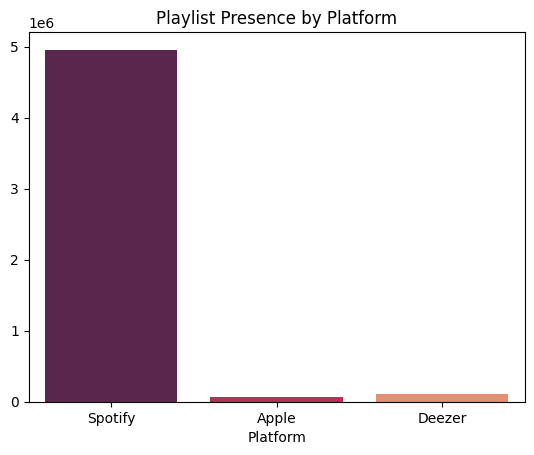

In [417]:
# Playlist Presence Comparison Across Platforms:

spotify_total = df["in_spotify_playlists"].sum()
apple_total = df["in_apple_playlists"].sum()
deezer_total = df["in_deezer_playlists"].sum()

platforms = {
    "Spotify": spotify_total,
    "Apple": apple_total,
    "Deezer": deezer_total
}

sns.barplot(x=platforms.keys(),y=platforms.values(), palette="rocket")
plt.title("Playlist Presence by Platform")
plt.xlabel("Platform")
plt.show()

D:\Temp\ipykernel_28320\2089711891.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platforms.keys(),y=platforms.values(),palette="crest")


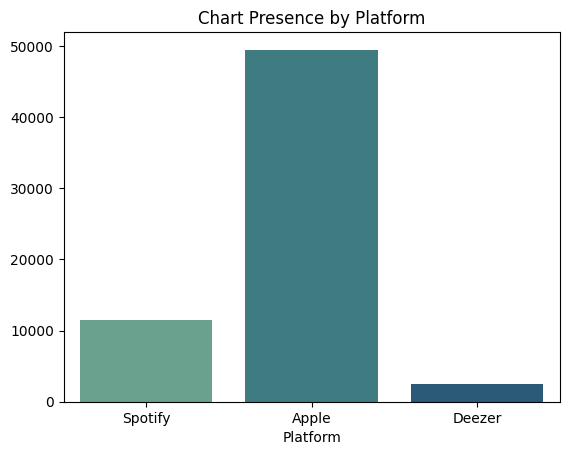

In [418]:
# Charts Presence Comparison Across Platforms:

spotifychart_total = df["in_spotify_charts"].sum()
applechart_total = df["in_apple_charts"].sum()
deezerchart_total = df["in_deezer_charts"].sum()

platforms = {
    "Spotify": spotifychart_total,
    "Apple": applechart_total,
    "Deezer": deezerchart_total
}

sns.barplot(x=platforms.keys(),y=platforms.values(),palette="crest")
plt.title("Chart Presence by Platform")
plt.xlabel("Platform")
plt.show()

In [419]:
# Average Playlist Presence per Platform:

avg_playlists = df[["in_spotify_playlists","in_apple_playlists","in_deezer_playlists"]].mean()
print("Average Playlist Count per Platform:")
print(avg_playlists)

Average Playlist Count per Platform:
in_spotify_playlists    5200.124869
in_apple_playlists        67.812172
in_deezer_playlists      109.740275
dtype: float64


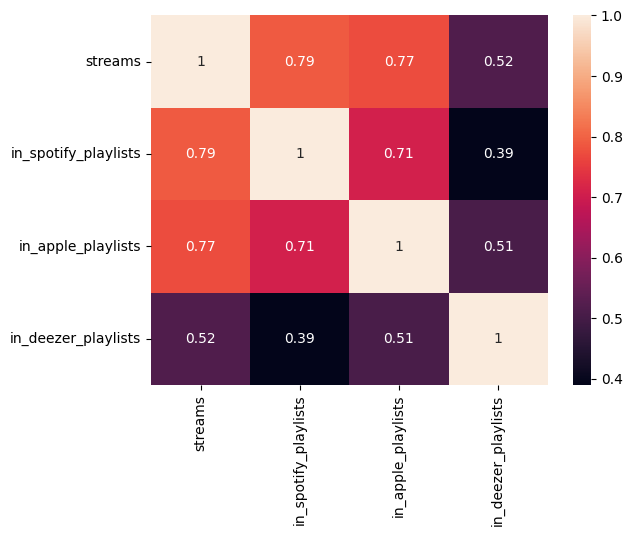

In [420]:
# Correlation Analysis: Streams vs Playlist Presence:

corr_matrix = df[["streams","in_spotify_playlists","in_apple_playlists","in_deezer_playlists"]].corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

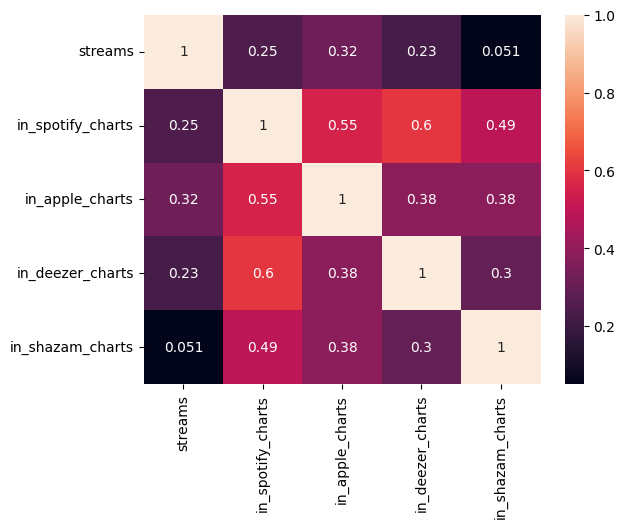

In [421]:
# Correlation Analysis: Streams vs Charts Presence:

corr_matrix = df[["streams","in_spotify_charts","in_apple_charts","in_deezer_charts","in_shazam_charts"]].corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [422]:
# Top 10 Songs by Total Playlist Presence:

df["total_playlist"] = df["in_spotify_playlists"] + df["in_apple_playlists"] + df["in_deezer_playlists"]
top_songs = df.sort_values("total_playlist",ascending=False).head(10).reset_index()
top_songs[["track_name","artist(s)_name","artist_count","release_date","streams","total_playlist"]]

,track_name,artist(s)_name,artist_count,release_date,streams,total_playlist
0,Get Lucky - Radio Edit,"Pharrell Williams, Nile Rodgers, Daft Punk",3,2013-01-01,9.338156e+08,53210.740275
1,Mr. Brightside,The Killers,1,2003-09-23,1.806618e+09,52394.740275
2,Wake Me Up - Radio Edit,Avicii,1,2013-01-01,1.970673e+09,51311.740275
3,Smells Like Teen Spirit - Remastered 2021,Nirvana,1,1991-09-10,1.690193e+09,50365.740275
4,Take On Me,a-ha,1,1984-10-19,1.479115e+09,45070.740275
5,Blinding Lights,The Weeknd,1,2019-11-29,3.703895e+09,44680.740275
6,One Dance,"Drake, WizKid, Kyla",3,2016-04-04,2.713922e+09,43799.740275
7,Somebody That I Used To Know,"Gotye, Kimbra",2,2011-01-01,1.457139e+09,43124.740275
8,Everybody Wants To Rule The World,Tears For Fears,1,1985-02-17,1.205952e+09,41961.740275
9,Sweet Child O' Mine,Guns N' Roses,1,1987-01-01,1.553498e+09,41568.740275


In [423]:
# Bottom 10 Songs by Total Playlist Presence:

df["total_playlist"] = df["in_spotify_playlists"] + df["in_apple_playlists"] + df["in_deezer_playlists"]
bottom_songs_songs = df.sort_values("total_playlist",ascending=True).head(10).reset_index()
bottom_songs_songs[["track_name","artist(s)_name","artist_count","release_date","streams","total_playlist"]]

,track_name,artist(s)_name,artist_count,release_date,streams,total_playlist
0,Peaches (from The Super Mario Bros. Movie),Jack Black,1,2023-04-07,68216992.0,34.0
1,Still With You,Jung Kook,1,2020-06-05,38411956.0,41.0
2,LAGUNAS,"Jasiel Nuï¿½ï¿½ez, Peso P",2,2023-06-22,39058561.0,64.0
3,Cheques,Shubh,1,2023-05-19,47956378.0,74.0
4,New Jeans,NewJeans,1,2023-07-07,29562220.0,89.0
5,Better Than Revenge (Taylor's Version),Taylor Swift,1,2023-07-07,30343206.0,92.0
6,Mi Bello Angel,Natanael Cano,1,2023-06-30,31873544.0,96.0
7,"Apna Bana Le (From ""Bhediya"")","Arijit Singh, Sachin-Jigar",2,2022-11-05,139836056.0,97.0
8,Don't ever say love me (feat. RM of BTS),"RM, Colde",2,2023-05-04,34502215.0,115.0
9,Mine (Taylor's Version),Taylor Swift,1,2023-07-07,36912123.0,126.0


In [424]:
# Top 10 Songs by Total Charts Presence:

df["total_chart"] = df["in_spotify_charts"] + df["in_apple_charts"] + df["in_deezer_charts"] + df["in_shazam_charts"]
top_songs = df.sort_values("total_chart",ascending=False).head(10).reset_index()
top_songs[["track_name","artist(s)_name","artist_count","release_date","streams","total_chart"]]

,track_name,artist(s)_name,artist_count,release_date,streams,total_chart
0,vampire,Olivia Rodrigo,1,2023-06-30,1.400040e+08,1283.0
1,Sprinter,"Dave, Central Cee",2,2023-06-01,1.837062e+08,1267.0
2,fukumean,Gunna,1,2023-05-15,9.521732e+07,1257.0
3,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023-07-14,1.413817e+08,1246.0
4,Tattoo,Loreen,1,2023-02-25,2.016609e+08,1104.0
5,I'm Good (Blue),"Bebe Rexha, David Guetta",2,2022-08-26,1.109433e+09,1036.0
6,Baby Don't Hurt Me,"David Guetta, Anne-Marie, Coi Leray",3,2023-04-06,1.777407e+08,998.0
7,The Next Episode,"Dr. Dre, Snoop Dogg",2,1999-01-01,8.433090e+08,994.0
8,Cruel Summer,Taylor Swift,1,2019-08-23,8.008408e+08,867.0
9,Miracle (with Ellie Goulding),"Calvin Harris, Ellie Goulding",2,2023-03-10,2.110508e+08,810.0


In [425]:
# Bottom 10 Songs by Total Charts Presence:

df["total_chart"] = df["in_spotify_charts"] + df["in_apple_charts"] + df["in_deezer_charts"] + df["in_shazam_charts"]
bottom_songs = df.sort_values("total_chart",ascending=True).head(10).reset_index()
bottom_songs[["track_name","artist(s)_name","artist_count","release_date","streams","total_chart"]]

,track_name,artist(s)_name,artist_count,release_date,streams,total_chart
0,Cigarettes,Juice WRLD,1,2021-12-10,185408548.0,0.0
1,In My Head,Lil Tjay,1,2022-04-01,190981339.0,0.0
2,Plan A,Paulo Londra,1,2022-03-23,240661097.0,0.0
3,"jealousy, jealousy",Olivia Rodrigo,1,2021-05-21,665765558.0,0.0
4,Die Young (feat. 347aidan),"Sleepy hallow, 347aidan",2,2022-05-25,160845341.0,0.0
5,Nos Comemos (feat. Ozuna),"Ozuna, Tiago pzk",2,2022-06-02,138334433.0,0.0
6,Thinking with My Dick,"Kevin Gates, Juicy J",2,2013-07-16,109091573.0,0.0
7,Chance,Paulo Londra,1,2022-04-06,89566512.0,0.0
8,Nail Tech,Jack Harlow,1,2022-02-18,193443895.0,0.0
9,Bussin,"Nicki Minaj, Lil Baby",2,2022-02-11,64714573.0,0.0


In [426]:
# Analysis of Songs by The Weeknd:

weeknd_df = df[df["artist(s)_name"].str.contains("Weeknd", case=False, na=False)]
print("Total Songs:", weeknd_df.shape[0])
print("Total Streams:", weeknd_df["streams"].sum())
print("Avg Streams:", weeknd_df["streams"].mean())

Total Songs: 37
Total Streams: 23929760757.0
Avg Streams: 646750290.7297298


In [427]:
# Top 5 Songs by The Weeknd:

weeknd_df.sort_values("streams", ascending=False).head(5)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,release_date,artist_list,solo_vs_collab,total_playlist,total_chart
55,Blinding Lights,The Weeknd,1,2019,11,29,43899,69,3.703895e+09,672,...,80,0,0,9,7,2019-11-29,[The Weeknd],Solo,44680.740275,339.176339
48,Starboy,"The Weeknd, Daft Punk",2,2016,9,21,29536,79,2.565530e+09,281,...,59,16,0,13,28,2016-09-21,"[The Weeknd, Daft Punk]",Collab,29926.740275,357.000000
325,The Hills,The Weeknd,1,2015,5,27,25744,4,1.947372e+09,122,...,57,9,0,14,8,2015-05-27,[The Weeknd],Solo,25975.740275,116.000000
47,Die For You,The Weeknd,1,2016,11,24,2483,59,1.647990e+09,68,...,52,9,0,15,7,2016-11-24,[The Weeknd],Solo,2575.000000,339.000000
164,Save Your Tears,The Weeknd,1,2020,3,20,12688,13,1.591224e+09,197,...,82,2,0,50,3,2020-03-20,[The Weeknd],Solo,12997.000000,328.000000


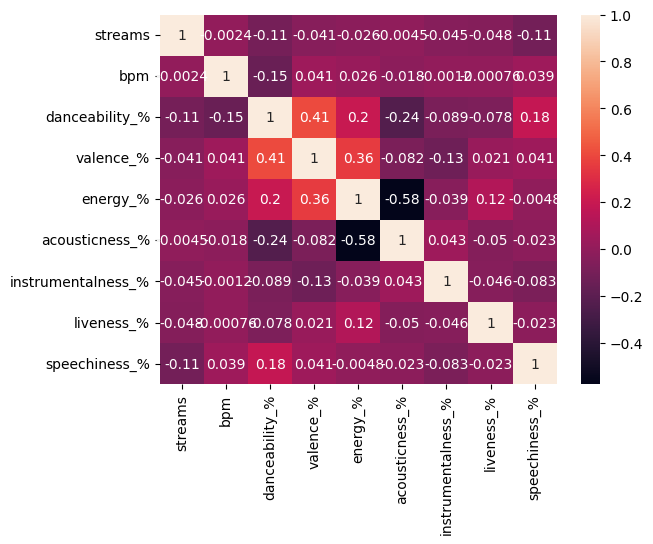

In [428]:
# Correlation Analysis of Audio Features with Streams:

features = df[['streams','bpm','danceability_%','valence_%','energy_%','acousticness_%','instrumentalness_%','liveness_%','speechiness_%']].corr()
sns.heatmap(features, annot=True)
plt.show()

In [429]:
high_streams = df["streams"].quantile(0.7)
low_playlists = df["total_playlist"].quantile(0.3)

viral_songs = df[
    (df["streams"] >= high_streams) &
    (df["total_playlist"] <= low_playlists)
]

viral_songs[["track_name","artist(s)_name","streams","total_playlist"]].head(10)

,track_name,artist(s)_name,streams,total_playlist
425,Dream On,Aerosmith,8.385868e+08,173.0
619,Enemy - from the series Arcane League of Legends,"Imagine Dragons, League of Legends, Arcane",1.223481e+09,840.0


In [430]:
low_streams = df["streams"].quantile(0.3)
high_playlists = df["total_playlist"].quantile(0.7)


overhyped_songs = df[
    (df["streams"] <= low_streams) &
    (df["total_playlist"] >= high_playlists)
]

overhyped_songs[["track_name","artist(s)_name","streams","total_playlist"]].head(10)

,track_name,artist(s)_name,streams,total_playlist
61,Boy's a liar Pt. 2,"PinkPantheress, Ice Spice",156338624.0,5440.000000
88,Makeba,Jain,165484133.0,6319.740275


Scatter Plot showing relationship between Total Playlists and Streams:


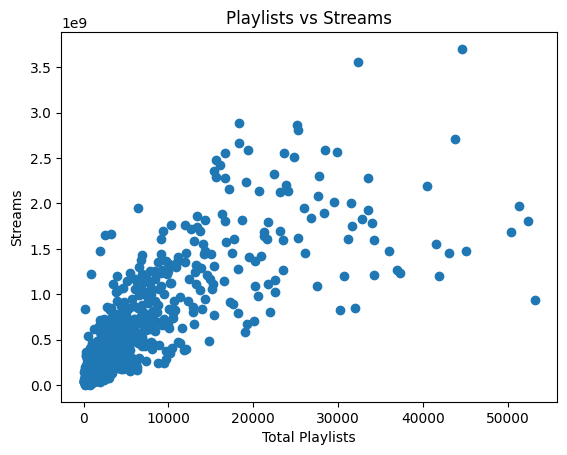

In [431]:
# Scatter Plot: Total Playlists vs Streams:

print("Scatter Plot showing relationship between Total Playlists and Streams:")

plt.scatter(df["total_playlist"], df["streams"])
plt.xlabel("Total Playlists")
plt.ylabel("Streams")
plt.title("Playlists vs Streams")
plt.show()

In [432]:
# Feature Importance Analysis: Top Songs vs Overall Dataset:

high_streams_threshold = df["streams"].quantile(0.8)
top_songs = df[df["streams"] >= high_streams_threshold]

avg_values = df.mean(numeric_only=True)
top_values = top_songs.mean(numeric_only=True)

comparison = pd.DataFrame({
    "Average": avg_values,
    "Top Songs": top_values
})

comparison["Difference"] = comparison["Top Songs"] - comparison["Average"]

comparison.sort_values("Difference", ascending=False).head(10)

,Average,Top Songs,Difference
streams,5.141374e+08,1.468926e+09,9.547881e+08
total_playlist,5.377677e+03,1.676574e+04,1.138806e+04
in_spotify_playlists,5.200125e+03,1.629746e+04,1.109734e+04
in_deezer_playlists,1.097403e+02,2.924334e+02,1.826931e+02
in_apple_playlists,6.781217e+01,1.758429e+02,1.080308e+02
total_chart,1.177608e+02,1.776677e+02,5.990686e+01
in_apple_charts,5.190871e+01,7.925654e+01,2.734784e+01
in_shazam_charts,5.117634e+01,7.279332e+01,2.161698e+01
in_spotify_charts,1.200944e+01,2.052880e+01,8.519352e+00
in_deezer_charts,2.666317e+00,5.089005e+00,2.422688e+00


In [433]:
# Bucket Analysis: Danceability vs Average Streams

def dance_bucket(val):
    if val <= 40:
        return "low"
    elif val <= 70:
        return "medium"
    else:
        return "high"
    
df["dance_bucket"] = df["danceability_%"].apply(dance_bucket)
df.groupby("dance_bucket")["streams"].mean().sort_values(ascending=False)

dance_bucket
low       6.648868e+08
medium    5.386470e+08
high      4.699726e+08
Name: streams, dtype: float64

In [434]:
# Bucket Analysis: valence vs Average Streams

def valence_bucket(val):
    if val <= 46:
        return "low"
    else:
        return "high"
    
df["valence_bucket"] = df["valence_%"].apply(valence_bucket)
df.groupby("valence_bucket")["streams"].mean().sort_values(ascending=False)

valence_bucket
low     5.291558e+08
high    5.028253e+08
Name: streams, dtype: float64

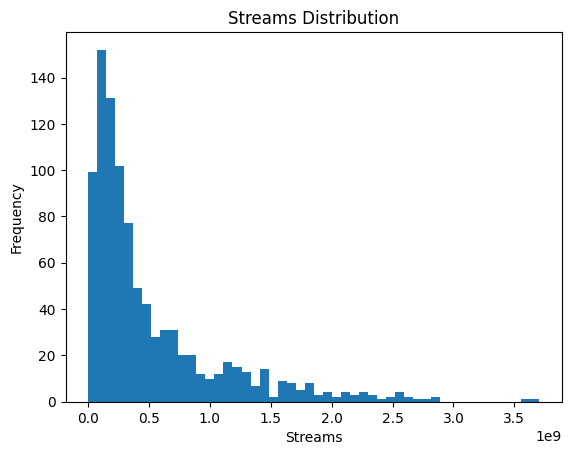

In [435]:
# Distribution of Streams:

plt.hist(df['streams'], bins=50)
plt.title("Streams Distribution")
plt.xlabel("Streams")
plt.ylabel("Frequency")
plt.show()